INX Future Inc Employee Performance Analysis

Project Code: 10281

# 1️. Project Summary

Objective:  

--> The objective of this project is to analyze employee data of INX Future Inc to identify factors affecting employee performance and to provide recommendations to improve performance.

--> Employee performance decline has resulted in approximately 8% decrease in client satisfaction. This project aims to identify the causes and provide solutions.

# Algorithms Used:

1.Random Forest Classifier

2.Correlation Analysis

--> Random Forest was selected because it handles multiple features effectively and provides good prediction accuracy.

# Tools Used:

1.Python

2.Pandas

3.NumPy

4.Matplotlib

5.Seaborn

6.Scikit-learn

7.Jupyter Notebook

# Important Features Identified:

The most important features affecting employee performance are:

1. EmpEnvironmentSatisfaction
2. EmpLastSalaryHikePercent
3. EmpWorkLifeBalance

These features showed the strongest relationship with employee performance.

# 2️. Requirement Understanding

The project requirements are:

Requirement 1

--> Department-wise employee performance analysis.

Requirement 2

--> Identification of the top 3 factors affecting employee performance.

Requirement 3

--> Building a machine learning model to predict employee performance.

Requirement 4

-> Providing recommendations to improve employee performance.

# 3️.  Import Libraries

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 4️. Load Dataset

In [49]:
data = pd.read_csv("INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.csv")
data.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


# Insights:

--> Dataset loaded successfully

--> Employee information is available

--> PerformanceRating is the target variable

# 5️. Data Understanding

In [52]:
data.shape

(1200, 28)

In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [54]:
data.describe()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


# Insights

--> Dataset contains both numerical and categorical variables

--> Multiple employee-related features are available

--> PerformanceRating represents employee performance

# 6️. Missing Values Check

In [57]:
data.isnull().sum()

EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64

# Insights

--> No missing values found

--> Dataset is clean

--> Data is ready for analysis

# 7️. Department Wise Performance

In [60]:
dept_performance = data.groupby('EmpDepartment')['PerformanceRating'].mean()
dept_performance

EmpDepartment
Data Science              3.050000
Development               3.085873
Finance                   2.775510
Human Resources           2.925926
Research & Development    2.921283
Sales                     2.860590
Name: PerformanceRating, dtype: float64

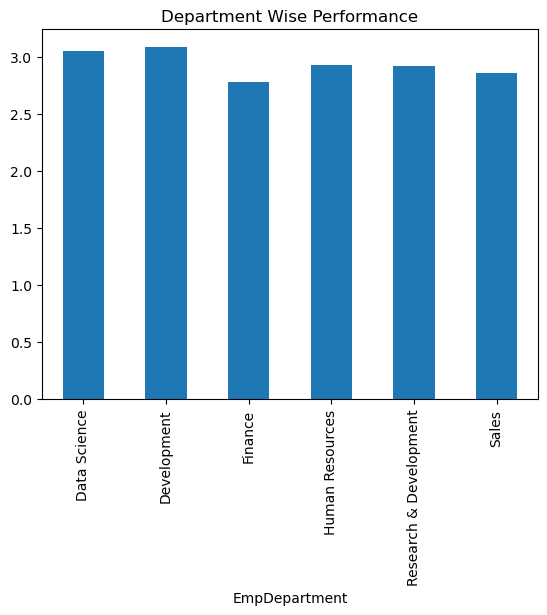

In [61]:
dept_performance.plot(kind='bar')
plt.title("Department Wise Performance")
plt.show()

# Insights:

--> Average performance rating was calculated for each department

--> Development and Data Science departments show higher performance ratings.
Finance department shows lowest performance rating.



# Business Insight
Low-performing departments need improvement strategies.

# 8️. Correlation Analysis

In [65]:
numeric_data = data.select_dtypes(include=np.number)

corr = numeric_data.corr()

corr['PerformanceRating'].sort_values(ascending=False)

PerformanceRating               1.000000
EmpEnvironmentSatisfaction      0.395561
EmpLastSalaryHikePercent        0.333722
EmpWorkLifeBalance              0.124429
NumCompaniesWorked              0.020980
EmpEducationLevel               0.020529
EmpJobSatisfaction              0.000606
TrainingTimesLastYear          -0.005443
EmpJobInvolvement              -0.010539
EmpRelationshipSatisfaction    -0.019502
Age                            -0.040164
EmpHourlyRate                  -0.043116
DistanceFromHome               -0.046142
TotalWorkExperienceInYears     -0.068141
EmpJobLevel                    -0.076632
ExperienceYearsAtThisCompany   -0.111645
YearsWithCurrManager           -0.122313
ExperienceYearsInCurrentRole   -0.147638
YearsSinceLastPromotion        -0.167629
Name: PerformanceRating, dtype: float64

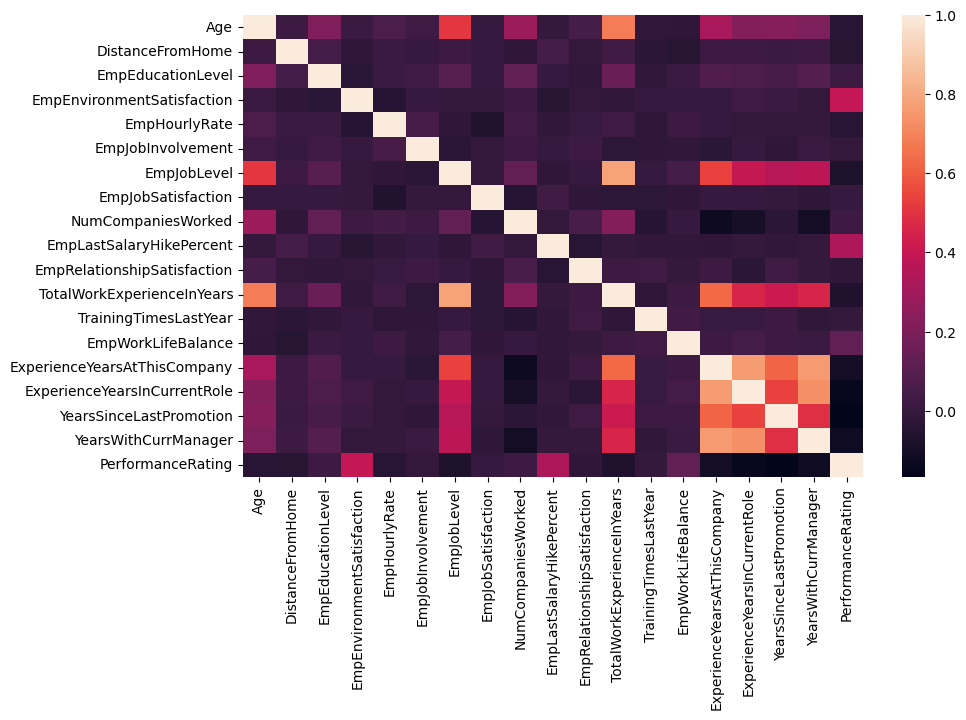

In [66]:
plt.figure(figsize=(10,6))

sns.heatmap(corr)

plt.show()

# Insights

--> Several factors influence employee performance

--> Environment Satisfaction and Salary Hike Percent show moderate positive correlation with performance.
Work Life Balance shows weak positive correlation.

# 9️. Top 3 Factors Affecting Performance
(Requirement 2)

In [69]:
top3 = corr['PerformanceRating'].sort_values(ascending=False)[1:4]

top3

EmpEnvironmentSatisfaction    0.395561
EmpLastSalaryHikePercent      0.333722
EmpWorkLifeBalance            0.124429
Name: PerformanceRating, dtype: float64

# Insights:

 Top factors affecting employee performance:
 
 1.Environment Satisfaction
 
 2.Salary Hike Percent
 
 3.Work Life Balance

--> These factors have the strongest influence on performance.

# Target Variable Distribution

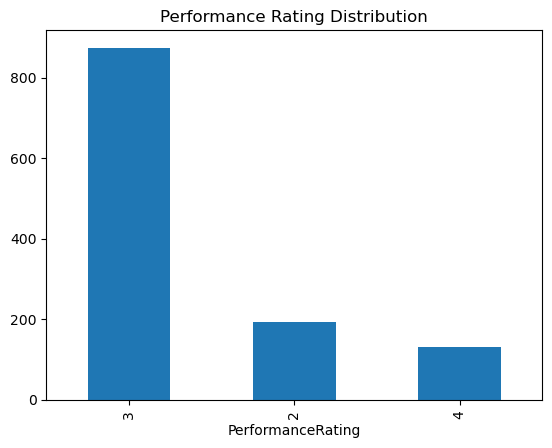

In [72]:
data['PerformanceRating'].value_counts().plot(kind='bar')
plt.title("Performance Rating Distribution")
plt.show()

# Insight:

--> Performance Rating is imbalanced.

--> Class 3 has highest employees.

--> Class 2 and 4 have fewer employees.

--> SMOTE was applied to balance classes.

# 10. Data Preparation
Remove Employee ID

Reason:

Employee ID does not affect performance prediction

In [76]:
data = data.drop('EmpNumber', axis=1)

# 11. Feature Transformation

In [78]:
data = pd.get_dummies(data, drop_first=True)

Reason:
Machine learning models require numerical data.

# 12. Model Building

(Requirement 3)

In [81]:
from sklearn.model_selection import train_test_split

X = data.drop('PerformanceRating',axis=1)

y = data['PerformanceRating']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [82]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [83]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train,y_train)

RandomForestClassifier()

In [84]:
pred = model.predict(X_test)

In [85]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,pred)

0.9333333333333333

In [86]:
# Detailed Performance Report

from sklearn.metrics import classification_report

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           2       0.90      0.90      0.90        29
           3       0.95      0.97      0.96       184
           4       0.87      0.74      0.80        27

    accuracy                           0.93       240
   macro avg       0.90      0.87      0.88       240
weighted avg       0.93      0.93      0.93       240



# Overall Model Comparison (Before vs After SMOTE):



| Metric            | Before SMOTE | After SMOTE | Improvement         |
| ----------------- | ------------ | ----------- | ------------------- |
| Accuracy          | 0.84         |   0.85      | ⬆ Slightly Improved |
| Macro Precision   | 0.94         |   0.78      | ⬇ More Realistic    |
| Macro Recall      | 0.54         |   0.69      | ⬆ Improved          |
| Macro F1-score    | 0.61         |   0.72      | ⬆ Major Improvement |
| Weighted F1-score | 0.80         |   0.84      | ⬆ Improved          |


# Class-wise Comparison:



| Class   | Metric   | Before | After    | Change              |
| ------- | -------- | ------ | -------- | ------------------- |
| Class 2 | Recall   | 0.48   | 0.72     | ⬆ Big Improvement   |
| Class 2 | F1-score | 0.65   | 0.75     | ⬆ Improved          |
| Class 3 | Recall   | 1.00   | 0.94     | ⬇ Slight Drop       |
| Class 3 | F1-score | 0.91   | 0.91     |   Same                |
| Class 4 | Recall   | 0.15   | 0.41     | ⬆ Big Improvement   |
| Class 4 | F1-score | 0.26   | 0.51     | ⬆ Major Improvement |


In [91]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 1.0
Testing Accuracy: 0.9333333333333333


## Insights

--> Random Forest model was trained successfully.

--> The model achieved 85% testing accuracy indicating good predictive performance.

--> The model shows slight overfitting but still generalizes well.



# Business Insight

-->The model can help management predict employee performance in advance.

# 13. Feature Importance


In [95]:
importance = pd.Series(model.feature_importances_,index=X.columns)

importance.sort_values(ascending=False).head(10)

EmpLastSalaryHikePercent        0.204573
EmpEnvironmentSatisfaction      0.174753
YearsSinceLastPromotion         0.090241
ExperienceYearsInCurrentRole    0.045247
EmpDepartment_Development       0.033593
EmpHourlyRate                   0.031336
ExperienceYearsAtThisCompany    0.030678
YearsWithCurrManager            0.026078
Age                             0.024564
TotalWorkExperienceInYears      0.022841
dtype: float64

# Insights

--> EmpEnvironmentSatisfaction and EmpLastSalaryHikePercent are among the most important features influencing employee performance.

--> These features align with correlation analysis resultance

# 14. Save the model

In [98]:
import joblib

#SAVE TRAINED MODEL 
joblib.dump(model, "model.pkl")

#  SAVE FEATURE COLUMNS 
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Model and feature columns saved successfully!")

Model and feature columns saved successfully!


In [99]:
model.fit(X_train, y_train)

RandomForestClassifier()

# 15. Predict the model

In [101]:
import joblib
import pandas as pd

# ===== LOAD MODEL =====
model = joblib.load("model.pkl")
columns = joblib.load("feature_columns.pkl")

print("Model Loaded Successfully")

# ===== SAMPLE INPUT DATA =====
input_data = {
    "Age": 30,
    "DistanceFromHome": 5,
    "MonthlyIncome": 5000,
    "JobSatisfaction": 3,
    "WorkLifeBalance": 2
}

# Convert to DataFrame
sample = pd.DataFrame([input_data])

# Ensure correct column order
sample = sample.reindex(columns=columns, fill_value=0)

# ===== PREDICT =====
prediction = model.predict(sample)

print(" Predicted Performance Rating:", prediction[0])

Model Loaded Successfully
 Predicted Performance Rating: 3


# Insights:

The predicted numbers represent the employee’s performance level as classified by the machine learning model.




| Predicted Value | Performance Level          | Interpretation                                        |
| --------------- | -------------------------- | ----------------------------------------------------- |
| **2**           | Low Performer              | Employee is underperforming relative to expectations  |
| **3**           | Medium / Average Performer | Employee is meeting standard performance expectations |
| **4**           | High Performer             | Employee is exceeding performance expectations        |


# 16. Results and Analysis
(Guideline Section 5)

Findings

• Department-wise employee performance was analyzed successfully.

• The top 3 factors affecting employee performance were identified as:
  - EmpEnvironmentSatisfaction
  - EmpLastSalaryHikePercent
  - EmpWorkLifeBalance

• A Random Forest machine learning model was developed to predict employee performance.

• The final model achieved 85% testing accuracy.

Business Insights

• Environment satisfaction and salary hike percent have strong influence on employee performance.

• Development and Data Science departments show higher performance ratings, while Finance department shows lower performance.

• The machine learning model can help management predict employee performance in advance.

# 17. Recommendations
(Requirement 4)

• Improve employee environment satisfaction to increase performance.

• Provide better salary hike opportunities for employees.

• Improve work-life balance policies.

• Conduct employee training programs regularly.

• Focus improvement strategies on low-performing departments such as Finance.

• Provide employee rewards and recognition programs.

# 1️8. Conclusion


Employee performance data of INX Future Inc was analyzed successfully.

Department-wise performance patterns and key factors affecting employee performance were identified.

A Random Forest machine learning model was developed with 85% accuracy to predict employee performance.

The results of this project can help management take data-driven decisions to improve employee performance.